# Microwave-optical transduction: state fidelity sanity check

Here we compute the transduction fidelity straight from the input-output relation as an operator expectation value, for both number-state and coherent-state inputs.
Recall that the optical output field is given by the following equation:

$$
\hat{a}_\mathrm{out} 
=
S_{11}\hat{a}_\mathrm{in} + S_{12}\hat{b}_\mathrm{in} 
+ S_{13}\hat{a}_\mathrm{in}^\dagger + S_{14}\hat{b}_\mathrm{in}^\dagger
+ L_{11}\hat{\xi}_a + L_{12}\hat{\xi}_b 
+ L_{13}\hat{\xi}_a^\dagger + L_{14}\hat{\xi}_b^\dagger 
.
$$

$\hat{a}_\mathrm{in}$ is the input optical mode; $\hat{b}_\mathrm{in}$ is the input microwave mode; and internal input modes are $\hat{\xi}_a$ and $\hat{\xi}_b$.
Consider the case of an input microwave Fock state, with all other modes in vacuum: 

$$
| \psi_\mathrm{in} \rangle = | 0, n_\mathrm{in}, 0 , 0 \rangle
$$

The state fidelity is given by the overlap probability

$$
\mathcal{F}_n 
= 
\langle \psi_\mathrm{in} |
\rho_\mathrm{out}
| \psi_\mathrm{in} \rangle
.
$$

Since $\hat{a}_\mathrm{out}$ mixes several input modes, we take this diagonal element from
the number-state projector in normal-ordered form:

$$
|n\rangle \langle n| 
= 
\sum_{m\ge n}
\frac{(-1)^{m-n}}{(m-n)!n!}
(\hat{a}^\dagger)^m \hat{a}^m
\quad\Longrightarrow\quad
\mathcal{F}_n 
= 
\sum_{m\ge n}
\frac{(-1)^{m-n}}{(m-n)!n!}
\big\langle
(\hat{a}_\mathrm{out}^\dagger)^m (\hat{a}_\mathrm{out})^m 
\big\rangle_\mathrm{in}
.
$$

Here the expectation value is taken with respect to the input state.
In the ideal case for transduction $S_{12} = 1$ and $\hat{a}_\mathrm{out} = \hat{b}_\mathrm{in}$ and thus $\mathcal{F}_n=1$.

### The number-state projector in normal-ordered form

The identity above follows from the generating function [`a.pdf` Eq. (53), or Cahill &amp; Glauber, Phys. Rev.
**177**, 1857 (1969), Eqs. (4.35)&ndash;(4.36)]:

$$
{:}e^{-\lambda\,\hat{a}^\dagger\hat{a}}{:}
=
\sum_{n\ge 0}(1-\lambda)^n |n\rangle \langle n|
=
\sum_{m\ge 0}\frac{(-\lambda)^m}{m!} \hat{a}^{\dagger m} \hat{a}^m
$$

Expanding $(1-\lambda)^n = \sum_{j=0}^{n} \binom{n}{j} (-\lambda)^j$, 

$$
\sum_{n\ge 0} \left( \sum_{j=0}^{n} \binom{n}{j} (-\lambda)^j \right) |n\rangle \langle n| 
=
\sum_{m\ge 0} \frac{(-\lambda)^m}{m!} \hat{a}^{\dagger m} \hat{a}^m
.
$$

Matching the coefficient of $(-\lambda)^m$ to each side gives us

$$
\sum_{n\ge m} \binom{n}{m} |n\rangle \langle n| 
=
\frac{1}{m!} \hat{a}^{\dagger m} \hat{a}^m
.
$$

Finally, we invert the binomial to obtain

$$
|n\rangle \langle n| 
=
\sum_{m\ge n} (-1)^{m-n} \binom{m}{n}
\frac{1}{m!} \hat{a}^{\dagger m} \hat{a}^m
=
\sum_{m\ge n} \frac{(-1)^{m-n}}{(m-n)!n! }
\hat{a}^{\dagger m} \hat{a}^m
.
$$

### The coherent-state projector

A similar normal-order projector can be constructed for a coherent state following [`a.pdf` Eq. (54)]:

$$
|\alpha\rangle \langle\alpha|
=
{:}e^{-(\hat{a}^\dagger - \alpha^*)(\hat{a} - \alpha)}{:}
=
\sum_{k\ge 0} \frac{(-1)^k}{k!}
(\hat{a}^\dagger - \alpha^*)^k (\hat{a} - \alpha)^k
,
$$

where we have set $n = 0$.
Consider the case of an input microwave coherent state, with all other modes in vacuum: 

$$
| \psi_\mathrm{in} \rangle = | 0, \alpha_\mathrm{in}, 0 , 0 \rangle
$$

so with $\alpha_\mathrm{in} = \sqrt{\bar{n}}$, the fidelity is obtained from

$$
\mathcal{F}_\alpha
=
\langle\alpha| \rho_\mathrm{out} |\alpha\rangle
=
\sum_{m\ge 0} \frac{(-1)^m}{m!}
\big\langle 
(\hat{a}_\mathrm{out}^\dagger - \alpha^*)^m (\hat{a}_\mathrm{out} - \alpha)^m
\big\rangle_\mathrm{in}
.
$$

In [1]:
from math import factorial

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

from src.plots import *
from src.params import *
from src import (Transducer, aout_moments,
                 Phi_fock, Phi_coherent, fidelity)

# Enable SVG in Jupyter notebooks.
%config InlineBackend.figure_formats = ['svg']

In [2]:
# Devices to compare (see src/params.py).
scenarios = {
    'Rochman et al.' : ROCHMAN_PARAMS,
    'King et al.' : KING_PARAMS,
}

# Out-coupling: False uses the experimental values; True sets eta_a = eta_b = 1.
IDEAL_COUPLING = True

In [3]:
def transduced_channel(params):
    """
    Phase-corrected (S, L) and noise moments at the transduction resonance.
    """

    # Apply ideal out-coupling if requested.
    p = {**params, 'eta_a': 1.0, 'eta_b': 1.0} if IDEAL_COUPLING else params

    # Parasitic squeezing ratio z = |g_bp/g_bs|, from the theory value (Delta_a).
    z = 1 / abs(1 - (p['omega_b'] / p['Delta_a'])**2)

    g_t = np.sqrt(p['kappa_a'] * p['kappa_b']) / 2    # Transduction rate.
    g_s = z * g_t                                     # Two-mode squeezing rate.

    # Transducer at the transduction resonance, Delta = +omega_b.
    transducer = Transducer.from_params(p, Delta=p['omega_b'])

    # Phase-corrected scattering at the central frequency of transduction.
    S, L = transducer.channel(p['omega_b'], g_t, g_s)
    return S, L, aout_moments(S, L)

In [4]:
def optical_output_mode(S, L, dims):
    """
    Optical output mode operator a_out on the four-mode Hilbert space.

    Arguments
    ---------
    S, L : ndarray
        Phase-corrected scattering and internal-loss matrices; only the first
        row (the optical output) is used.
    dims : int or sequence of 4 ints
        Hilbert-space dimension per mode, ordered (a_in, b_in, xi_a, xi_b).
        A scalar uses the same dimension for every mode.
    """

    # If only one dims is given, broadcast to all modes.
    if np.isscalar(dims):
        dims = (dims,) * 4

    # Annihilation operator for mode k, identity on the other three modes.
    def mode(k):
        ops = [qt.qeye(dim) for dim in dims]
        ops[k] = qt.destroy(dims[k])
        return qt.tensor(ops)

    # Setup each mode annhilation operator.
    a_in, b_in, xi_a, xi_b = mode(0), mode(1), mode(2), mode(3)

    # First rows of the scattering and internal-loss matrices.
    S_11, S_12, S_13, S_14 = S[0]
    L_11, L_12, L_13, L_14 = L[0]

    # Linear combination of input and noise operators, Eq. (app-eqn:aout).
    return (
        S_12 * b_in + S_14 * b_in.dag()
        + S_11 * a_in + S_13 * a_in.dag()
        + L_11 * xi_a + L_12 * xi_b + L_13 * xi_a.dag() + L_14 * xi_b.dag()
        )


def fock_fidelity(S, L, n, d):
    """
    Number-state fidelity F_n = <n|rho_out|n> from the normal-ordered projector,

        F_n = <ψ_in| Σ_{m≥n} (-1)^{m-n}/((m-n)! n!) (a_out^m)† a_out^m |ψ_in>

    where |ψ_in> = |0, n, 0, 0>.

    Arguments
    ---------
    S, L : ndarray
        Phase-corrected scattering and internal-loss matrices.
    n : int
        Fock state number.
    d : int
        Hilbert-space dimension per mode.
    """

    # Construct output optical mode.
    a_out = optical_output_mode(S, L, d)

    # Input state: |n> in the b_in mode, vacuum elsewhere.
    psi_in = qt.tensor(qt.basis(d, 0), qt.basis(d, n), qt.basis(d, 0), qt.basis(d, 0))

    # Compute fidelity term-by-term.
    F = 0.0
    for m in range(n + 20):
        if m >= n:
            F += (-1)**(m-n) / (factorial(m-n) * factorial(n)) * psi_in.norm()**2
        psi_in = a_out * psi_in

    return F


def coherent_fidelity(S, L, nbar, K=8):
    """
    Coherent-state fidelity F_alpha = <alpha|rho_out|alpha>, alpha = sqrt(nbar),
    from the displaced projector (a.pdf Eq. 54),

        F_alpha = <ψ_in| Σ_{m≥0} (-1)^m/m! ((a_out - alpha)^m)† (a_out - alpha)^m |ψ_in>.

    where |ψ_in> = |0, α, 0, 0>.

    Arguments
    ---------
    S, L : ndarray
        Phase-corrected scattering and internal-loss matrices.
    nbar : float
        Mean photon number of the coherent input.
    K : int
        Number of terms kept in the series (a handful is plenty).
    """

    # Coherent state amplitude.
    alpha = np.sqrt(nbar)

    # Signal mode: room for the coherent state plus the K ladder steps.
    # Vacuum modes: only ever K-excited.
    d_sig = int(nbar + 10*np.sqrt(nbar)) + 3*K + 12
    d_vac = K + 3

    # Construct shifted optical output mode.
    a_out = optical_output_mode(S, L, (d_vac, d_sig, d_vac, d_vac))
    shift = a_out - alpha * qt.qeye([d_vac, d_sig, d_vac, d_vac])

    # Input state: |alpha> in the b_in mode, vacuum elsewhere.
    psi = qt.tensor(
        qt.basis(d_vac, 0), qt.coherent(d_sig, alpha), qt.basis(d_vac, 0), qt.basis(d_vac, 0)
        )

    # Compute fidelity term-by-term.
    F = 0.0
    for k in range(K):
        F += (-1)**k / factorial(k) * psi.norm()**2
        psi = shift * psi

    return F

In [5]:
n_fock = np.arange(1, 16)              # Number states (integer photon number).
nbar_coh = np.linspace(1.0, 15.0, 15)  # Coherent states (mean photon number).

results = {}
for name, params in scenarios.items():
    S, L, moments = transduced_channel(params)

    # Number-state fidelity: operator series vs. characteristic-function reference.
    F_fock = np.array([fock_fidelity(S, L, n, d=n+6) for n in n_fock])
    F_fock_ref = np.array([fidelity(lambda w: Phi_fock(w, n), *moments) for n in n_fock])

    # Coherent-state fidelity: operator series vs. characteristic-function reference.
    F_coh = np.array([coherent_fidelity(S, L, nbar) for nbar in nbar_coh])
    F_coh_ref = np.array([fidelity(lambda w: Phi_coherent(w, np.sqrt(nbar)), *moments) for nbar in nbar_coh])

    # Store results.
    results[name] = dict(
        F_fock = F_fock, 
        F_fock_ref = F_fock_ref,
        F_coh = F_coh, 
        F_coh_ref = F_coh_ref
        )

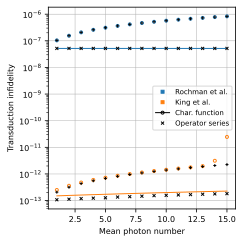

In [6]:
# Figure setup.
fig, axs = plt.subplots(
    nrows = 1,
    ncols = 1,
    figsize = (
        1 * FIG_SIZES['onecol'],
        1 * FIG_SIZES['onecol']
        ),
    )

# Colormap.
colors = {
    'Rochman et al.': 'tab:blue', 
    'King et al.': 'tab:orange'
    }

# Iterate through results.
for name, r in results.items():
    c = colors[name]

    # Characteristic-function reference (src/fidelity.py): markers (number), line (coherent).
    axs.plot(n_fock,   1 - r['F_fock_ref'], 'o', color=c, mfc='none')
    axs.plot(nbar_coh, 1 - r['F_coh_ref'],  '-', color=c)

    # Operator expectation value (this notebook): overlaid '+' (number), 'x' (coherent).
    axs.plot(n_fock,   1 - r['F_fock'], '+', color='k')
    axs.plot(nbar_coh, 1 - r['F_coh'],  'x', color='k')

# Fake plots to label devices and methods.
for name, c in colors.items():
    axs.plot([], [], 's', color=c, label=name)
axs.plot([], [], 'k', marker='o', mfc='none', ls='-', label='Char. function')
axs.plot([], [], 'k', marker='x', ls='', label='Operator series')

# Scale and grid.
axs.semilogy()
axs.grid('both')

# Axis labels and legend.
axs.set_xlabel('Mean photon number')
axs.set_ylabel('Transduction infidelity')
axs.legend()

# Save figure.
fig.tight_layout()
fig.savefig('fig/sanity_check.pdf', bbox_inches='tight')